# Lesson 2 — Conditional Edges & Branching Logic

## What you will learn
- `add_conditional_edges()` — the most powerful feature of LangGraph
- **Routing functions** — Python functions that decide which node to visit next
- How to build `if/else` branching workflows

## Mental model
```
START
  ↓
[classify]  ←── reads the review, sets sentiment
  ↓  (routing function decides)
  ├── positive → [handle_positive] → END
  ├── negative → [handle_negative] → END
  └── neutral  → [handle_neutral]  → END
```

## Key difference from Lesson 1
In Lesson 1, edges were **fixed**: `A always goes to B`.  
In Lesson 2, edges are **dynamic**: `A goes to B, C, or D depending on state`.

In [2]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

## Step 1 — Define the State

In [4]:
class ReviewState(TypedDict):
    review: str       # input: the user's review text
    sentiment: str    # set by classify_node
    response: str     # set by whichever handler runs

## Step 2 — Define Nodes

In [5]:
def classify_node(state: ReviewState) -> dict:
    text = state["review"].lower()
    if any(w in text for w in ["great", "love", "excellent", "amazing", "good"]):
        sentiment = "positive"
    elif any(w in text for w in ["bad", "terrible", "hate", "awful", "worst"]):
        sentiment = "negative"
    else:
        sentiment = "neutral"
    print(f"  → Sentiment: {sentiment}")
    return {"sentiment": sentiment}


def handle_positive(state: ReviewState) -> dict:
    return {"response": "Thank you so much! We're thrilled you had a great experience! ⭐⭐⭐⭐⭐"}


def handle_negative(state: ReviewState) -> dict:
    return {"response": "We're truly sorry. Please contact support and we'll make it right. 🙏"}


def handle_neutral(state: ReviewState) -> dict:
    return {"response": "Thank you for your feedback. We appreciate every opinion! 😊"}

## Step 3 — The Routing Function

This is the heart of conditional edges.  
It **reads** the current state and **returns a string** — the name of the next node.

> **Rule:** The return value must exactly match a node name (or `END`).

In [6]:
def route_by_sentiment(state: ReviewState) -> Literal["handle_positive", "handle_negative", "handle_neutral"]:
    sentiment = state["sentiment"]
    if sentiment == "positive":
        return "handle_positive"
    elif sentiment == "negative":
        return "handle_negative"
    else:
        return "handle_neutral"

## Step 4 — Build the Graph

In [7]:
graph_builder = StateGraph(ReviewState)

graph_builder.add_node("classify", classify_node)
graph_builder.add_node("handle_positive", handle_positive)
graph_builder.add_node("handle_negative", handle_negative)
graph_builder.add_node("handle_neutral", handle_neutral)

# Fixed edge: always start at classify
graph_builder.add_edge(START, "classify")

# CONDITIONAL edge: after classifying, use route_by_sentiment to decide
graph_builder.add_conditional_edges(
    "classify",              # from this node
    route_by_sentiment,      # call this function to decide where to go
    {                        # map return value → node name
        "handle_positive": "handle_positive",
        "handle_negative": "handle_negative",
        "handle_neutral":  "handle_neutral",
    }
)

# All paths end at END
graph_builder.add_edge("handle_positive", END)
graph_builder.add_edge("handle_negative", END)
graph_builder.add_edge("handle_neutral", END)

graph = graph_builder.compile()
print("Graph compiled!")

Graph compiled!


## Step 5 — Visualize

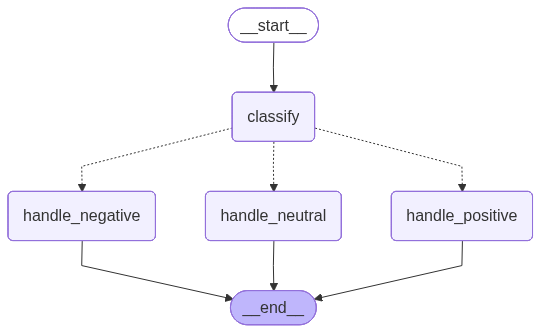

In [8]:
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Visualization unavailable: {e}")
    print("Nodes:", list(graph.get_graph().nodes.keys()))

## Step 6 — Test It

In [9]:
test_reviews = [
    "This product is absolutely amazing! I love it!",
    "Terrible experience, worst purchase I ever made.",
    "It arrived on time. The packaging was standard.",
]

for review in test_reviews:
    print(f"\n📝 Review: {review}")
    result = graph.invoke({"review": review, "sentiment": "", "response": ""})
    print(f"💬 Response: {result['response']}")


📝 Review: This product is absolutely amazing! I love it!
  → Sentiment: positive
💬 Response: Thank you so much! We're thrilled you had a great experience! ⭐⭐⭐⭐⭐

📝 Review: Terrible experience, worst purchase I ever made.
  → Sentiment: negative
💬 Response: We're truly sorry. Please contact support and we'll make it right. 🙏

📝 Review: It arrived on time. The packaging was standard.
  → Sentiment: neutral
💬 Response: Thank you for your feedback. We appreciate every opinion! 😊


## Key Takeaways

| Concept | How it works |
|---------|-------------|
| `add_conditional_edges(src, fn, map)` | After `src`, call `fn(state)` and route to `map[result]` |
| Routing function | Returns a **string** — must match a key in the map |
| `Literal[...]` type hint | Documents all possible return values |
| Multiple paths | Each branch can have completely different logic |

## 🏋️ Exercise
1. Add a `"very_positive"` sentiment category (words: `incredible`, `outstanding`, `phenomenal`)
2. Add a `handle_very_positive` node with an even more enthusiastic reply
3. Update `route_by_sentiment` and register the new node + edge
4. Test it with: `"This is absolutely phenomenal, outstanding quality!"`

In [ ]:
# Your exercise solution here
